In [1]:
from abc import ABC, abstractmethod
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

class Model(ABC):
    """Abstract base class for forecasting models."""

    model: object  # underlying model object

    @abstractmethod
    def train(self, Xtr: pd.DataFrame, ytr: pd.Series) -> None:
        """Fit the model on training data."""
        ...

    @abstractmethod
    def predict(self, Xva: pd.DataFrame) -> np.ndarray:
        """Return predictions."""
        ...

class RidgeBaseModel(Model):
    """Ridge regression model using only the raw x feature."""

    def __init__(self, alpha: float = 1.0, random_state: int = 0) -> None:
        self.model = Ridge(alpha=alpha, random_state=random_state)

    def train(self, Xtr: pd.DataFrame, ytr: pd.Series) -> None:
        self.model.fit(Xtr, ytr)

    def predict(self, Xva: pd.DataFrame) -> np.ndarray:
        return self.model.predict(Xva)

class DataGenerator(ABC):
    """Abstract base class for data generators."""

    @abstractmethod
    def generate(
        self, n: int, std: float, start: float, end: float
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Generate (x, y) samples where x is drawn uniformly from [start, end]
        and y is a deterministic function of x plus Gaussian noise N(0, std).

        Parameters
        ----------
        n     : total number of samples (train + test)
        std   : standard deviation of the additive Gaussian noise
        start : lower bound of the x range
        end   : upper bound of the x range

        Returns
        -------
        train_df : DataFrame with columns ['x', 'y'] — 80 % of samples
        test_df  : DataFrame with columns ['x', 'y'] — 20 % of samples
        """
        ...


# Assignment 3 Part 1 — Synthetic Data Generation & Limits of Ridge Regression (50%)

## Background

A **Ridge regression** model is a *linear* model: it can only learn a weighted sum  
$\hat{y} = w_0 + w_1 x$
When the true relationship between $x$ and $y$ is non-linear, the model's predictions will
be systematically wrong — not because of noise in the data, but because the model
**cannot represent** the true function.

This assignment asks you to:

1. Implement a synthetic data generator whose signal is $y = \sin(x) + \varepsilon$,  
   $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, with $x \in [0, 2\pi]$. (5%)
2. Train the provided `RidgeBaseModel` (raw $x$ feature only) on the generated data. (already provided)
3. Demonstrate that the **Mean Absolute Error (MAE)** on the test set is substantially  
   larger than the noise standard deviation `std` you passed to the generator —  
   proving the error comes from the model's inability to fit a sinusoid, not from noise. (already provided)
4. Add x^2, x^3, x^4 and x^5 as features in MultiFeaturesSinDataGenerator (5%)
   
   Show the MAE/variance < 1 and visualize ridge model is trainable on these data (10%)
5. Create a CustomDataGenerator class that can archive higher MAE with x^2, x^3, x^4 and x^5 features (15%)
   
   MAE/variance > 1 is mandatory, the higher the better
6. Explain why CustomDataGenerator is more harder for Ridge Model to learn (15%)

## Instructions

Run the first code cell to load all base classes, then complete each task below in order.

## Submission

Just submit this ipynb file, make sure you explain everything in the markdown cells

---
## Task 1 — Implement `SinDataGenerator`

Implement the concrete class `SinDataGenerator` that inherits from `DataGenerator`.

### Requirements

| Requirement | Detail |
|---|---|
| **x** | Sample `n` values **uniformly** from `[start, end]` using `rng.uniform` |
| **y** | Compute `y = sin(x) + ε` where `ε ~ N(0, std)` using `rng.normal` |
| **Split** | Use the first **80 %** rows as training set and remaining **20 %** as test set |
| **Return** | A tuple `(train_df, test_df)` — each a `DataFrame` with columns `['x', 'y']` |
| **Reproducibility** | Accept a `random_state` constructor parameter (default `42`) and seed via `np.random.default_rng` |

> **Why does this make Ridge fail?**  
> $\sin(x)$ is non-linear. A Ridge model with only the raw feature $x$ can only fit a straight line
> $\hat{y} = w_0 + w_1 x$. On $[0, 2\pi]$, $\sin(x)$ is symmetric around zero, so the
> best-fit line is essentially flat. The model's irreducible error (bias) stays large
> regardless of how small `std` is.

In [2]:
# ── Task 1: your implementation goes here ──────────────────────────────────────

class SinDataGenerator(DataGenerator):
    """Generates (x, y) pairs where y = sin(x) + N(0, std), x uniform on [start, end].

    Parameters
    ----------
    random_state : int
        Seed for the random number generator (ensures reproducibility).
    """

    def __init__(self, random_state: int = 42) -> None:
        self.random_state = random_state

    def generate(
        self, n: int, std: float, start: float, end: float
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        # Step 1: create a reproducible RNG
        rng = np.random.default_rng(self.random_state)

        # Step 2: sample x uniformly from [start, end]
        x = rng.uniform(start, end, size=n)

        # ── TODO (Step 3): compute y ───────────────────────────────────────────
        # Use x and std to produce y = sin(x) + Gaussian noise.
        y = np.sin(x) + rng.normal(0, std, size=n)
        # ──────────────────────────────────────────────────────────────────────

        # Step 4: assemble into a DataFrame
        df = pd.DataFrame({'x': x, 'y': y})

        # Step 5: 80 / 20 train-test split (shuffle via the RNG)
        df = df.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        split = int(0.8 * n)
        train_df = df.iloc[:split].reset_index(drop=True)
        test_df  = df.iloc[split:].reset_index(drop=True)
        return train_df, test_df


---
## Task 2 — Train & Evaluate the Ridge Model (already provided)

Use your `SinDataGenerator` together with the provided `RidgeBaseModel` to run the
full pipeline:

1. Generate **500 samples** with `std = 0.1`, `start = 0`, `end = 2π`.
2. Train `RidgeBaseModel` on the training split using the single feature column `'x'`.
3. Predict on the test split.
4. Compute the **Mean Absolute Error (MAE)** on the test set.
5. Print a summary comparing MAE to the noise `std`.

The cell below is pre-written — run it after completing Task 1.  
**Expected result:** MAE should be several times larger than `std = 0.1`.

In [3]:
# ── Task 2: pipeline (run after completing Task 1) ─────────────────────────────

NOISE_STD = 0.1
N_SAMPLES  = 500

# 1. Generate data
generator = SinDataGenerator(random_state=42)
train_df, test_df = generator.generate(n=N_SAMPLES, std=NOISE_STD, start=0, end=2 * np.pi)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")

# 2. Train Ridge on the raw x feature only
ridge_model = RidgeBaseModel(alpha=1.0)
ridge_model.train(train_df[['x']], train_df['y'])

# 3. Predict on the test split
y_pred = ridge_model.predict(test_df[['x']])

# 4. Evaluate
mae = mean_absolute_error(test_df['y'], y_pred)

print(f"\n── Evaluation ──────────────────────────────")
print(f"Noise std               : {NOISE_STD:.4f}")
print(f"Test MAE (Ridge)        : {mae:.4f}")
print(f"MAE / std               : {mae / NOISE_STD:.2f}×")
print(f"\nConclusion: MAE is {'> std  ✓' if mae >  NOISE_STD else '<= std  (check your implementation)'}")


Train samples : 400
Test  samples : 100

── Evaluation ──────────────────────────────
Noise std               : 0.1000
Test MAE (Ridge)        : 0.3765
MAE / std               : 3.76×

Conclusion: MAE is > std  ✓


---
## Task 3 — Visualisation & Analysis (already provided, feel free to add your own for better understanding)

Run the cell below to generate a diagnostic plot.  It will show:

- The **true signal** $y = \sin(x)$ (solid curve).
- The **noisy training points** (scatter).
- The **Ridge prediction line** over the test range (dashed line).
- A **residual panel** showing the gap between $\hat{y}$ and the true $\sin(x)$.

**Short-answer questions (answer in the markdown cell that follows the plot):**

1. Why does the Ridge line appear nearly flat over $[0, 2\pi]$?
2. Why does increasing `std` (e.g. to `2.0`) not close the gap between MAE and `std`?
3. What change to the feature set would dramatically lower MAE while keeping `std` fixed?  
   *(Hint: think about what basis functions could represent $\sin(x)$.)*

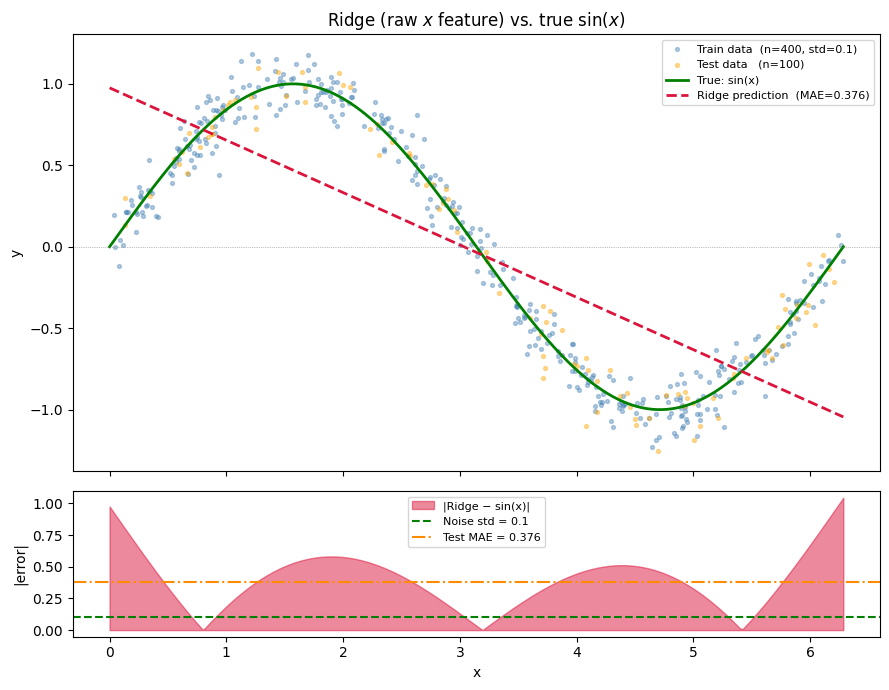

Plot saved to ridge_vs_sin.png


In [4]:
# ── Task 3: visualisation (run after Task 2) ───────────────────────────────────

x_curve = np.linspace(0, 2 * np.pi, 300)
y_true_curve = np.sin(x_curve)
y_ridge_curve = ridge_model.predict(pd.DataFrame({'x': x_curve}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# ── top panel: data + predictions ─────────────────────────────────────────────
ax1.scatter(train_df['x'], train_df['y'], s=8, alpha=0.4, color='steelblue',
            label=f'Train data  (n={len(train_df)}, std={NOISE_STD})')
ax1.scatter(test_df['x'],  test_df['y'],  s=8, alpha=0.4, color='orange',
            label=f'Test data   (n={len(test_df)})')
ax1.plot(x_curve, y_true_curve,   color='green',  lw=2, label='True: sin(x)')
ax1.plot(x_curve, y_ridge_curve,  color='crimson', lw=2, ls='--',
         label=f'Ridge prediction  (MAE={mae:.3f})')
ax1.axhline(0, color='gray', lw=0.5, ls=':')
ax1.set_ylabel('y')
ax1.set_title('Ridge (raw $x$ feature) vs. true $\\sin(x)$')
ax1.legend(fontsize=8)

# ── bottom panel: residuals |ŷ − sin(x)| ──────────────────────────────────────
residuals = np.abs(y_ridge_curve - y_true_curve)
ax2.fill_between(x_curve, residuals, alpha=0.5, color='crimson',
                 label='|Ridge − sin(x)|')
ax2.axhline(NOISE_STD, color='green', lw=1.5, ls='--',
            label=f'Noise std = {NOISE_STD}')
ax2.axhline(mae, color='darkorange', lw=1.5, ls='-.',
            label=f'Test MAE = {mae:.3f}')
ax2.set_xlabel('x')
ax2.set_ylabel('|error|')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ridge_vs_sin.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved to ridge_vs_sin.png")


Q1:

The Ridge regression model is inherently linear and assumes a functional form of $\hat{y} = w_0 + w_1 x$ which severely limits its expressive capacity. However, the true underlying function $\sin(x)$ is non-linear and periodic.

Over the interval $[0, 2\pi]$, $\sin(x)$ is symmetric around zero, meaning its average value is approximately zero. As a result, the optimal linear fit (in the least-squares sense) minimizes error by approximating the function with a nearly constant or weakly sloped line. This leads to the observed near-flat prediction.

This behavior reflects high model bias, where the model is too simple to capture the true data-generating process.


Q2:

Increasing the noise standard deviation $\sigma$ raises the level of irreducible error in the data. However, the dominant source of error in this setting is not noise, but model bias.

Because the Ridge model cannot represent non-linear relationships, it consistently underfits the data regardless of the noise level. Even as ( \sigma ) increases, the gap between the model’s predictions and the true function remains substantial.

Thus, the total prediction error can be decomposed as:

$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}$

In this case, the bias term dominates, so increasing noise does not meaningfully reduce the discrepancy between MAE and $\sigma$.


Q3:

To reduce MAE, the model must be given greater expressive power through feature engineering. Specifically, introducing polynomial features such as $x^2, x^3, x^4, x^5$ enables the model to approximate non-linear functions.

This is justified by the Taylor series expansion of $\sin(x)$:
$\sin(x) = x - \frac{x^3}{6} + \frac{x^5}{120} - \cdots$

By including these higher-order terms, the Ridge model effectively becomes a linear combination of polynomial basis functions, allowing it to approximate $\sin(x)$ much more accurately.

As a result, the model bias is significantly reduced, and the MAE approaches the noise level $\sigma$, indicating that the model is now capturing the underlying signal effectively.


---
## Task 4 — Implement `MultiFeaturesSinDataGenerator`

`SinDataGenerator` only gives Ridge a single feature `x`, forcing it to fit a straight line.
By adding the polynomial columns `x²`, `x³`, `x⁴`, `x⁵` you give the model a richer
basis that can approximate $\sin(x)$ much more closely.

### Step-by-step guidance

```
1. Call super().generate(n, std, start, end) to get (train_df, test_df)
2. For each degree d in {2, 3, 4, 5}, add a new column to both DataFrames
   whose values are the existing 'x' column raised to the power d.
   Name each column using the pattern 'x^d' (e.g. 'x^2', 'x^3', …).
3. Return (train_df, test_df)
```

> **Why does this help?**  
> Ridge now solves $\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + w_4 x^4 + w_5 x^5$.  
> The Taylor expansion of $\sin(x)$ is $x - \frac{x^3}{6} + \frac{x^5}{120} - \cdots$,  
> so odd-degree polynomial terms already capture the dominant shape.  
> The resulting MAE should drop to roughly the noise level `std`.

In [5]:
class MultiFeaturesSinDataGenerator(SinDataGenerator):
    """Extends SinDataGenerator by adding polynomial features x^2 … x^5.

    The returned DataFrames have columns ['x', 'x^2', 'x^3', 'x^4', 'x^5', 'y'],
    giving a Ridge model enough expressive power to approximate sin(x) closely.
    """

    def generate(
        self, n: int, std: float, start: float, end: float
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        train_df, test_df = super().generate(n, std, start, end)

        # TODO: add polynomial features x^2, x^3, x^4, x^5 to train_df and test_df ───────────────────────────────────────────
        for d in range (2, 6):
            train_df[f'x^{d}'] = train_df['x'] ** d
            test_df[f'x^{d}'] = test_df['x'] ** d
            
        return train_df, test_df


## Visualization

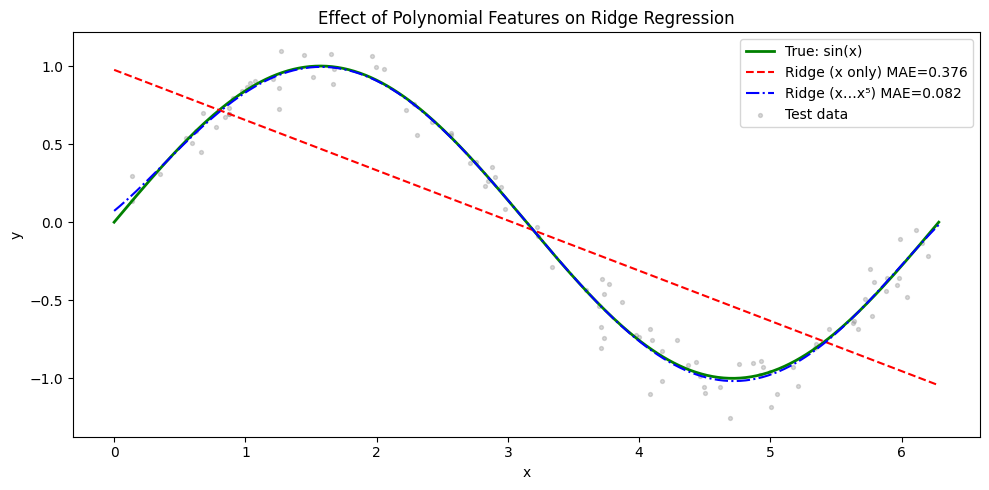

In [6]:
# ── Compare: Ridge on x  vs.  Ridge on x, x^2 … x^5 ──────────────────────────

NOISE_STD = 0.1
N_SAMPLES = 500

feature_cols_single = ['x']
feature_cols_poly   = ['x', 'x^2', 'x^3', 'x^4', 'x^5']

# Ridge on x
gen_single = SinDataGenerator(random_state=42)
tr_s, te_s = gen_single.generate(N_SAMPLES, NOISE_STD, 0, 2 * np.pi)

model_s = RidgeBaseModel(alpha=1.0)
model_s.train(tr_s[feature_cols_single], tr_s['y'])
pred_s = model_s.predict(te_s[feature_cols_single])
mae_s  = mean_absolute_error(te_s['y'], pred_s)

# Ridge on x, x^2 … x^5
gen_multi = MultiFeaturesSinDataGenerator(random_state=42)
tr_m, te_m = gen_multi.generate(N_SAMPLES, NOISE_STD, 0, 2 * np.pi)

model_m = RidgeBaseModel(alpha=1.0)
model_m.train(tr_m[feature_cols_poly], tr_m['y'])
pred_m = model_m.predict(te_m[feature_cols_poly])
mae_m  = mean_absolute_error(te_m['y'], pred_m)

# curve
x_curve = np.linspace(0, 2 * np.pi, 300)
y_true  = np.sin(x_curve)

# predictions
y_hat_s = model_s.predict(pd.DataFrame({'x': x_curve}))
poly_df = pd.DataFrame({f'x^{d}' if d > 1 else 'x': x_curve ** d for d in range(1, 6)})
y_hat_m = model_m.predict(poly_df)

# plot
plt.figure(figsize=(10, 5))

plt.plot(x_curve, y_true, color='green', lw=2, label='True: sin(x)')
plt.plot(x_curve, y_hat_s, color='red', linestyle='--',
         label=f'Ridge (x only) MAE={mae_s:.3f}')
plt.plot(x_curve, y_hat_m, color='blue', linestyle='-.',
         label=f'Ridge (x…x⁵) MAE={mae_m:.3f}')

plt.scatter(te_s['x'], te_s['y'], s=8, alpha=0.3, color='gray', label='Test data')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Effect of Polynomial Features on Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()


This visualization demonstrates that the limitation lies in the feature representation rather than the Ridge model itself. By introducing polynomial features, the model gains sufficient expressive power to approximate the non-linear function, significantly reducing bias.

---
# Task 5 - Custom Data Generator

In [7]:
class CustomDataGenerator(DataGenerator):
    """Custom data generator for a different function (e.g., cos(x) + noise).
    You can implement this class to generate data based on a different underlying
    Make sure provide x, x^2, … x^5 features in the returned DataFrames
    When use Ridge on these features, you should get MAE > noise std.
    However you should be able to have a model that performs better than Ridge on the raw x feature.
    """
    def __init__(self, random_state: int = 42) -> None:
        self.random_state = random_state  # Your code here: add any necessary initialization
    def generate(
        self, n: int, std: float, start: float, end: float
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        # Your code here: implement a different data generator
        rng = np.random.default_rng(self.random_state)

        x = rng.uniform(start, end, size=n)

        y = np.sin(10 * x) + rng.normal(0, std, size=n)

        df = pd.DataFrame({'x': x, 'y': y})

        for d in range(2, 6):
            df[f'x^{d}'] = df['x'] ** d

        df = df.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        split = int(0.8 * n)

        train_df = df.iloc[:split].reset_index(drop=True)
        test_df = df.iloc[split:].reset_index(drop=True)

        return train_df, test_df
        

# Help you visualize the difference and check your ration between MAE / noise_std

Model                                 Test MAE   MAE / std
----------------------------------------------------------
Ridge  (x only)                         0.5988       5.99×
Ridge  (x, x²…x⁵)                       0.5840       5.84×

Conclusion: MAE is > std  ✓


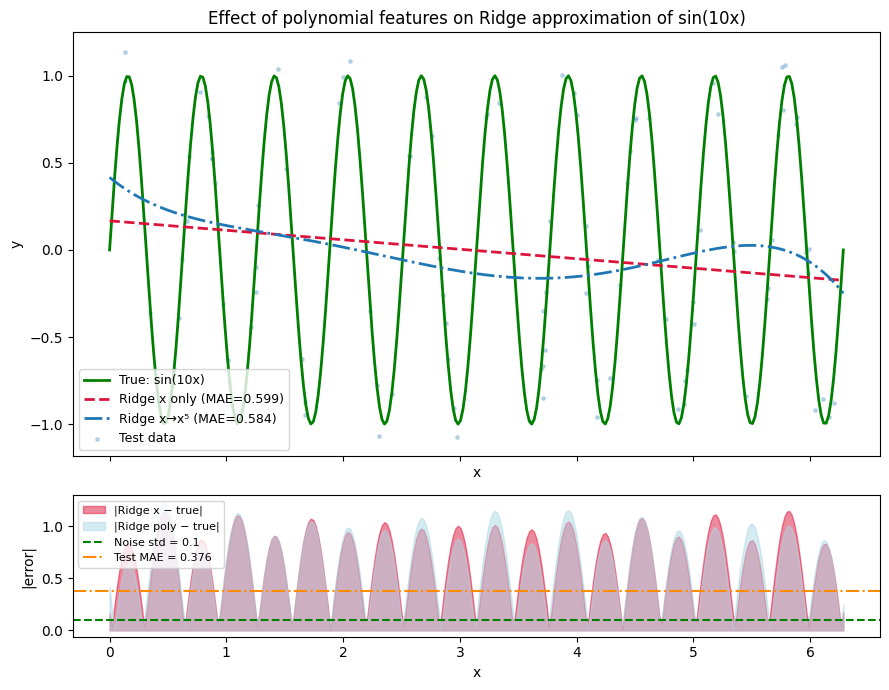

In [8]:
# ── Compare: Ridge on x  vs.  Ridge on x, x^2 … x^5 ──────────────────────────
NOISE_STD = 0.1
N_SAMPLES  = 500
feature_cols_single = ['x']
feature_cols_poly   = ['x', 'x^2', 'x^3', 'x^4', 'x^5']

# --- single-feature baseline --------------------------------------------------
gen_single = CustomDataGenerator()
tr_s, te_s = gen_single.generate(N_SAMPLES, NOISE_STD, 0, 2 * np.pi)

m_single = RidgeBaseModel(alpha=1.0)
m_single.train(tr_s[feature_cols_single], tr_s['y'])

pred_single = m_single.predict(te_s[feature_cols_single])
mae_single  = mean_absolute_error(te_s['y'], pred_single)

# --- multi-feature ------------------------------------------------------------
gen_multi = CustomDataGenerator()
tr_m, te_m = gen_multi.generate(N_SAMPLES, NOISE_STD, 0, 2 * np.pi)

m_multi = RidgeBaseModel(alpha=1.0)
m_multi.train(tr_m[feature_cols_poly], tr_m['y'])

pred_multi = m_multi.predict(te_m[feature_cols_poly])
mae_multi  = mean_absolute_error(te_m['y'], pred_multi)

# ── print results ─────────────────────────────────────────────────────────────
print(f"{'Model':<35} {'Test MAE':>10}  {'MAE / std':>10}")
print("-" * 58)
print(f"{'Ridge  (x only)':<35} {mae_single:>10.4f}  {mae_single/NOISE_STD:>9.2f}×")
print(f"{'Ridge  (x, x²…x⁵)':<35} {mae_multi:>10.4f}  {mae_multi/NOISE_STD:>9.2f}×")
print(f"\nConclusion: MAE is {'> std  ✓' if mae_multi > NOISE_STD else '<= std'}")

# ── curve data ───────────────────────────────────────────────────────────────
x_curve = np.linspace(0, 2 * np.pi, 300)
y_true = np.sin(10 * x_curve)

# predictions
y_hat_s = m_single.predict(pd.DataFrame({'x': x_curve}))

poly_df = pd.DataFrame({'x': x_curve})
for d in range(2, 6):
    poly_df[f'x^{d}'] = poly_df['x'] ** d

y_hat_m = m_multi.predict(poly_df)


# ─── plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x_curve, y_true, color='green', lw=2, label='True: sin(10x)')
ax1.plot(x_curve, y_hat_s, color='crimson', lw=2, ls='--',
        label=f'Ridge x only (MAE={mae_single:.3f})')
ax1.plot(x_curve, y_hat_m, lw=2, ls='-.',
        label=f'Ridge x→x⁵ (MAE={mae_multi:.3f})')
ax1.scatter(te_m['x'], te_m['y'], s=6, alpha=0.25,
           label='Test data')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Effect of polynomial features on Ridge approximation of sin(10x)')
ax1.legend(fontsize=9)

residual_single = np.abs(y_hat_s - y_true)
residual_poly = np.abs(y_hat_m - y_true)
ax2.fill_between(x_curve, residual_single, alpha=0.5, color='crimson',
                 label='|Ridge x − true|')
ax2.fill_between(x_curve, residual_poly, alpha=0.5, color='lightblue',
                 label='|Ridge poly − true|')
ax2.axhline(NOISE_STD, color='green', lw=1.5, ls='--',
            label=f'Noise std = {NOISE_STD}')
ax2.axhline(mae, color='darkorange', lw=1.5, ls='-.',
            label=f'Test MAE = {mae:.3f}')
ax2.set_xlabel('x')
ax2.set_ylabel('|error|')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig('ridge_vs_sin10x.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Task 6 - Explain why CustomDataGenerator is more harder for Ridge Model to learn

With polynomial features $x, x^2 … x^5$, the Ridge model gets a test MAE of about 0.584, which is around 5.84 times larger than the noise standard deviation (0.1). Although this is slightly better than using only x, the error is still quite large. This suggests that the model is not capturing the true pattern in the data very well.

In comparison, for $\sin(x)$, the same Ridge model achieves an MAE of 0.082, which is slightly below the noise level, showing that it can learn the underlying pattern effectively.

The main reason is that the feature representation does not match the true function. The data is generated from a high-frequency function: $y = \sin(10x)$ which changes very quickly over the interval $[0, 2\pi]$. From the plot, we can see that both Ridge models produce much smoother curves and fail to follow the rapid oscillations. This is a sign of underfitting.

Even with polynomial features up to degree 5, the model is still limited. Low-degree polynomials are generally smooth and work better for slowly changing functions like $\sin(x)$, but they are not flexible enough to approximate something like $\sin(10x)$.

We can also see this from the Taylor expansion: $\sin(kx) = kx - \frac{k^3 x^3}{6} + \frac{k^5 x^5}{120} - \cdots$ When k becomes larger (like k=10), the coefficients grow very fast. This means we would need higher-degree terms to get a good approximation. Since we only use up to $x^5$, the model cannot represent the function well.

Another reason is the Ridge regularization: $\min_\beta \sum (y - \hat{y})^2 + \lambda \sum \beta_j^2$ This pushes coefficients toward zero and makes the model even smoother. While this helps prevent overfitting, it also increases bias, which makes it harder to fit a function with rapid changes.

Overall, the combination of a high-frequency target, limited polynomial features, and Ridge regularization leads to high bias and large error. The CustomDataGenerator is harder for Ridge because it produces $\sin(10x)$ instead of a slowly varying function like $\sin(x)$. This leads to systematic underfitting: the model captures only a smooth, low-frequency trend while the true signal oscillates rapidly. This also shows that simply adding more features does not guarantee better performance — the features need to match the structure of the data.